<a href="https://colab.research.google.com/github/nhuwynh07/THDeepLearning/blob/main/DL_Tuan1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Đọc dữ liệu

In [3]:
cigaret = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/refs/heads/main/Data/04_CIGARET.csv")
df=pd.DataFrame(cigaret)
df.head()

,KgTar,KgNic,KgCO,MnTar,MnNic,MnCO,FLTar,FLNic,FLCO
0,20,1.1,16,16,1.1,15,5,0.4,4
1,27,1.7,16,13,0.8,17,16,1.0,19
2,27,1.7,16,16,1.0,19,17,1.2,17
3,20,1.1,16,9,0.9,9,13,0.8,18
4,20,1.1,16,14,0.8,17,13,0.8,18


2. Xem thông tin tổng quan:
- Dataset gồm 25 dòng và 9 cột
- Các thuộc tính kiểu số
- Không có missing value

In [4]:
print("Kích thước dữ liệu:", df.shape)
df.info()

Kích thước dữ liệu: (25, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   KgTar   25 non-null     int64  
 1   KgNic   25 non-null     float64
 2   KgCO    25 non-null     int64  
 3   MnTar   25 non-null     int64  
 4   MnNic   25 non-null     float64
 5   MnCO    25 non-null     int64  
 6   FLTar   25 non-null     int64  
 7   FLNic   25 non-null     float64
 8   FLCO    25 non-null     int64  
dtypes: float64(3), int64(6)
memory usage: 1.9 KB


3. Kiểm tra dữ liệu trùng lặp và xóa




In [5]:
print("Số dòng trùng lặp:", df.duplicated().sum())

Số dòng trùng lặp: 1


In [6]:
#Xóa dòng trùng lặp
df.drop_duplicates(inplace=True)

4. Thống kê mô tả dữ liệu

- Các thuộc tính có độ phân tán khác nhau, trong đó một số biến như Tar và CO có khoảng biến thiên lớn.

- Dữ liệu có thể tồn tại outlier



In [7]:
df.describe()


,KgTar,KgNic,KgCO,MnTar,MnNic,MnCO,FLTar,FLNic,FLCO
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,21.166667,1.262500,15.708333,12.916667,0.875000,14.875000,13.208333,0.920833,14.666667
std,3.292504,0.235561,0.954585,3.809789,0.247158,4.235589,3.753018,0.251913,4.269881
min,10.000000,1.000000,14.000000,2.000000,0.200000,3.000000,2.000000,0.200000,3.000000
25%,20.000000,1.100000,15.750000,12.750000,0.800000,14.750000,13.000000,0.800000,14.750000
50%,20.000000,1.100000,16.000000,13.500000,0.800000,16.500000,15.000000,1.000000,15.500000
75%,23.000000,1.400000,16.000000,15.250000,1.000000,17.000000,15.000000,1.100000,17.250000
max,27.000000,1.800000,18.000000,19.000000,1.400000,22.000000,17.000000,1.300000,19.000000


5. Histogram phân phối dữ liệu


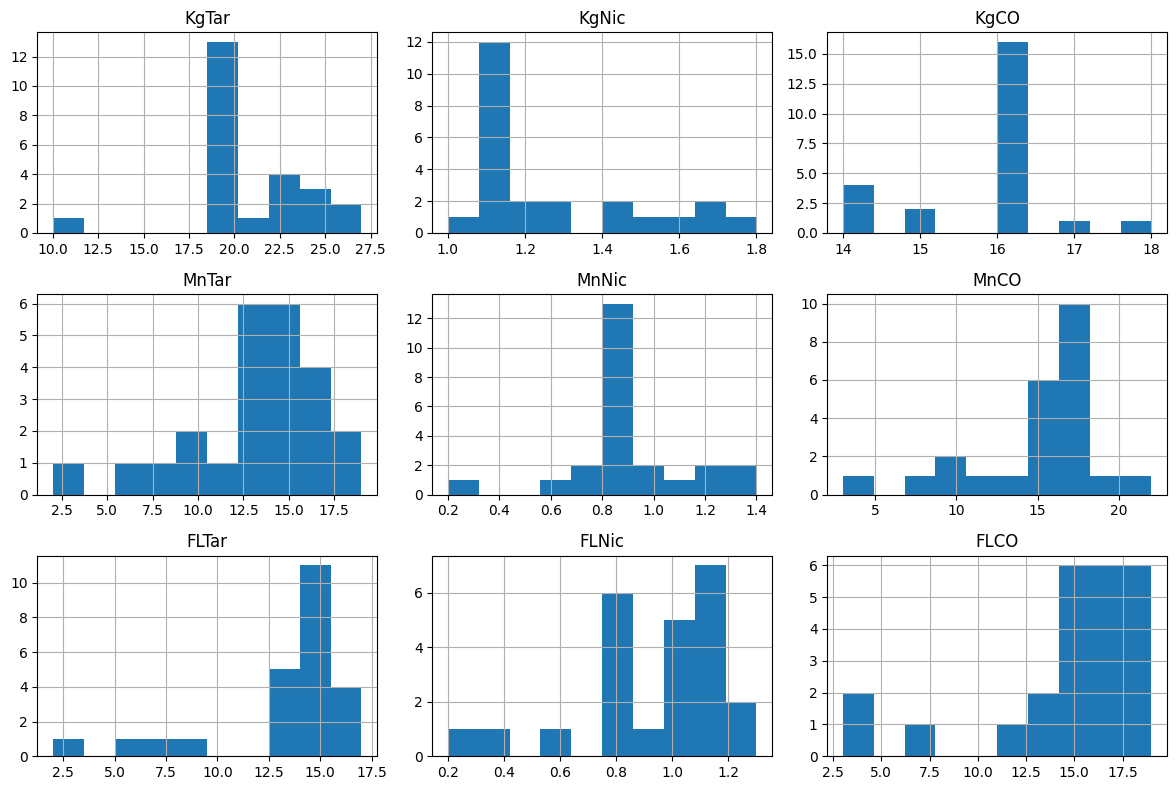

In [8]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

6. Kiểm tra Outlier bằng Boxplot

Dataset tồn tại khá nhiều outlier ở các thuộc tính Tar, Nicotine và CO

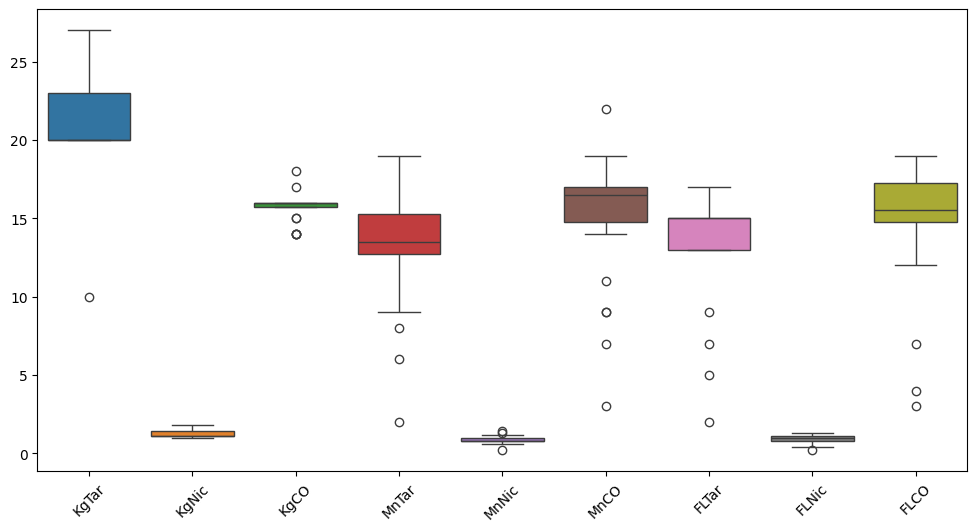

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

7. Phát hiện Oitlier bằng IQR

In [10]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outlier = ((df < (Q1 - 1.5 * IQR)) |
           (df > (Q3 + 1.5 * IQR)))

print(outlier.sum())

KgTar    1
KgNic    0
KgCO     8
MnTar    3
MnNic    3
MnCO     6
FLTar    4
FLNic    1
FLCO     3
dtype: int64


8. Xử lý Outlier bằng cách loại bỏ

In [11]:
df_clean = df[~((df < (Q1 - 1.5 * IQR)) |
                (df > (Q3 + 1.5 * IQR))).any(axis=1)]


In [12]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 1 to 13
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   KgTar   8 non-null      int64  
 1   KgNic   8 non-null      float64
 2   KgCO    8 non-null      int64  
 3   MnTar   8 non-null      int64  
 4   MnNic   8 non-null      float64
 5   MnCO    8 non-null      int64  
 6   FLTar   8 non-null      int64  
 7   FLNic   8 non-null      float64
 8   FLCO    8 non-null      int64  
dtypes: float64(3), int64(6)
memory usage: 640.0 bytes


9. Heatmap
- KgTar và KgNic có tương quan dương rất mạnh (0.99)
- FLTar và FLNic có tương quan dương mạnh (0.91)
- KgTar và FLTar có tương quan dương khá cao (0.77)
- FLNic và FLCO có tương quan âm (-0.42)

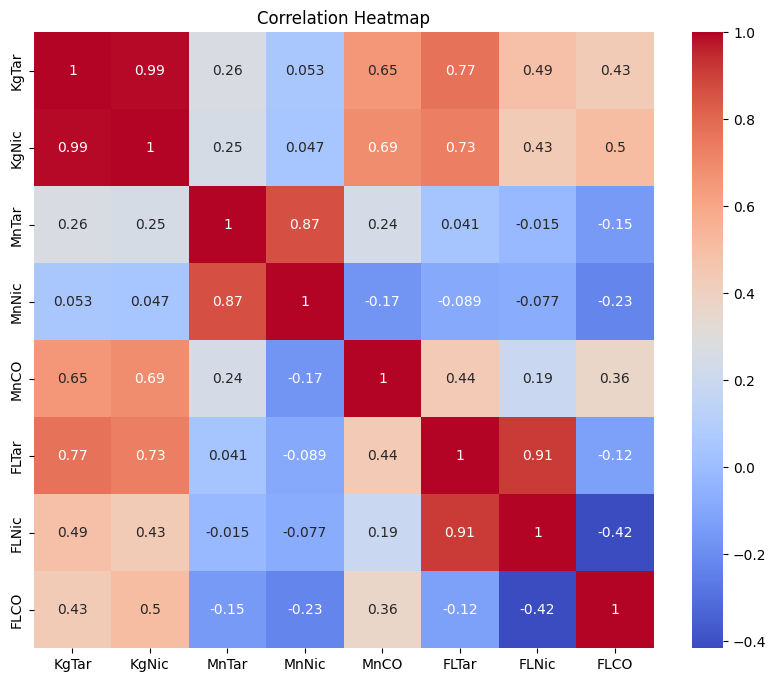

In [15]:
plt.figure(figsize=(10,8))
# Sau bước xử lý outlier, biến KgCO chỉ còn một giá trị duy nhất nên phương sai bằng 0.
# Loại bỏ cột constant
df_clean = df_clean.loc[:, df_clean.nunique() > 1]

sns.heatmap(df_clean.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()